In [ ]:
pip install opencv-python mediapipe numpy pandas

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 26.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import json
import glob
import numpy as np
import pandas as pd
import mediapipe as mp
import gc  # Garbage Collector interface
from datetime import datetime
from google.colab import drive

# ================= CONFIGURATION =================
# Mount Drive (Run this only once in a separate cell usually)
# drive.mount('/content/drive')

# Base Directory containing all subject folders (unzipped)
# Structure: /content/drive/MyDrive/Dataset/subject_01/, /subject_02/...
DATASET_ROOT = "/content/drive/MyDrive/Behaviour Dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Processed_Clips_v2"

IMG_SIZE = 224
CLIP_LENGTH = 16
STRIDE = 8
MAX_MISSING_FACES = 8  # 50% allowed missing

# ================= HELPER FUNCTIONS =================

def map_attention(score):
    """Maps 1-5 scale to 3 classes."""
    if score <= 2.4: return 0      # Low
    elif score <= 3.6: return 1    # Mid
    else: return 2                 # High

def parse_timestamp(ts_str, is_filename=False):
    """Parses timestamp strings into datetime objects."""
    try:
        if is_filename:
            # Filename: 12_41_05_323716.jpg
            base = os.path.splitext(ts_str)[0]
            parts = base.split('_')
            clean = f"{parts[0]}:{parts[1]}:{parts[2]}.{parts[3]}"
        else:
            # JSON: 12:41:05:323716
            parts = ts_str.split(':')
            clean = f"{parts[0]}:{parts[1]}:{parts[2]}.{parts[3]}"
        return datetime.strptime(clean, "%H:%M:%S.%f")
    except Exception:
        return None

import bisect

def get_aggregated_labels(label_dir, image_files):
    """
    1. Aggregates 4 labelers (Average if overlapping at same time).
    2. Creates a chronological timeline of events.
    3. Assigns labels to images using 'Step Function' logic:
       (Image gets the label of the most recent past timestamp).
    """
    json_files = glob.glob(os.path.join(label_dir, "*.json"))

    # --- Step 1: Collect & Average Events ---
    # We group by timestamp string to handle multiple labelers at the same instant.
    timestamp_map = {}

    for jf in json_files:
        with open(jf, 'r') as f:
            data = json.load(f)
            for entry in data:
                ts_str = entry.get('datetime')

                # Check if attention value exists
                if 'attention' not in entry or entry['attention'] == "":
                    continue

                try:
                    val = float(entry['attention'])
                    if ts_str not in timestamp_map:
                        timestamp_map[ts_str] = []
                    timestamp_map[ts_str].append(val)
                except ValueError:
                    continue

    # Create the Master Timeline
    # Format: [(datetime_obj, avg_score), ...]
    timeline = []
    for ts_str, scores in timestamp_map.items():
        avg_score = sum(scores) / len(scores)
        ts_obj = parse_timestamp(ts_str)
        if ts_obj:
            timeline.append((ts_obj, avg_score))

    # Sort strictly by time
    timeline.sort(key=lambda x: x[0])

    if not timeline:
        print("   [Warning] No valid labels found.")
        return {}

    # Separate into keys (times) and values (scores) for binary search
    timeline_times = [x[0] for x in timeline]
    timeline_scores = [x[1] for x in timeline]

    img_labels = {}
    dropped_count = 0

    # --- Step 2: Assign Labels (Forward Fill) ---
    for img_path in image_files:
        img_name = os.path.basename(img_path)
        img_ts = parse_timestamp(img_name, is_filename=True)

        if not img_ts: continue

        # Binary Search: Find where this image fits in the timeline
        # bisect_right returns the insertion point to maintain order.
        # index - 1 is the "most recent past" label.
        idx = bisect.bisect_right(timeline_times, img_ts) - 1

        if idx >= 0:
            # Found a valid past label
            raw_avg = timeline_scores[idx]
            final_class = map_attention(raw_avg)
            img_labels[img_name] = final_class
        else:
            # Image is BEFORE the very first label -> Drop it
            dropped_count += 1

    print(f"   -> Assigned labels to {len(img_labels)} frames.")
    print(f"   -> Dropped {dropped_count} frames (occurred before first label).")

    return img_labels

def process_single_subject(subject_path, output_dir):
    subject_id = os.path.basename(subject_path)

    # Paths
    img_dir = os.path.join(subject_path, "images")
    lbl_dir = os.path.join(subject_path, "labels")

    if not os.path.exists(img_dir): return

    print(f"\n[{subject_id}] Reading images...")
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))

    if len(img_files) < CLIP_LENGTH:
        print(f"[{subject_id}] Not enough images. Skipping.")
        return

    # 1. Get Labels
    labels_map = get_aggregated_labels(lbl_dir, img_files)
    print(f"[{subject_id}] Matched {len(labels_map)} labeled frames.")

    # 2. Initialize MediaPipe (Short Range = Faster on CPU)
    mp_face = mp.solutions.face_detection
    detector = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.5)

    # Buffers
    X_clips = []
    y_clips = []

    buffer_imgs = []
    buffer_lbls = []
    buffer_imputed = [] # 0=Real, 1=Imputed

    last_box = None # (x, y, w, h)

    print(f"[{subject_id}] Processing video stream...")

    # Process frames
    for img_path in img_files:
        fname = os.path.basename(img_path)
        if fname not in labels_map: continue

        # Read
        frame = cv2.imread(img_path)
        if frame is None: continue

        h_img, w_img, _ = frame.shape
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Detect
        results = detector.process(rgb)

        # Crop Logic
        crop = None
        is_imputed = 0

        if results.detections:
            # Face Found
            det = results.detections[0].location_data.relative_bounding_box
            x = int(det.xmin * w_img)
            y = int(det.ymin * h_img)
            w = int(det.width * w_img)
            h = int(det.height * h_img)

            # Padding
            pad = 15
            x, y = max(0, x-pad), max(0, y-pad)
            w, h = min(w_img-x, w+2*pad), min(h_img-y, h+2*pad)

            last_box = (x, y, w, h)
            crop = frame[y:y+h, x:x+w]

        elif last_box is not None:
            # Face Lost -> Use Memory
            x, y, w, h = last_box
            crop = frame[y:y+h, x:x+w]
            is_imputed = 1

        # If no face found yet, skip
        if crop is None: continue

        # Resize & Normalize
        try:
            crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
            # Keep uint8 (0-255) to save RAM! Normalize during training.
            # Using float32 here increases RAM usage by 4x.
        except:
            continue

        # Add to buffer
        buffer_imgs.append(crop)
        buffer_lbls.append(labels_map[fname])
        buffer_imputed.append(is_imputed)

        # Create Clip
        if len(buffer_imgs) == CLIP_LENGTH:
            # Quality Check
            if sum(buffer_imputed) <= MAX_MISSING_FACES:
                # Majority Vote for Label
                cls = max(set(buffer_lbls), key=buffer_lbls.count)

                X_clips.append(np.array(buffer_imgs))
                y_clips.append(cls)

            # Stride: Remove first N elements
            buffer_imgs = buffer_imgs[STRIDE:]
            buffer_lbls = buffer_lbls[STRIDE:]
            buffer_imputed = buffer_imputed[STRIDE:]

    # Save to Disk immediately
    if len(X_clips) > 0:
        X_arr = np.array(X_clips, dtype=np.uint8) # Save as int to save space
        y_arr = np.array(y_clips, dtype=np.int64)

        out_x = os.path.join(output_dir, f"{subject_id}_X.npy")
        out_y = os.path.join(output_dir, f"{subject_id}_y.npy")

        np.save(out_x, X_arr)
        np.save(out_y, y_arr)

        print(f"[{subject_id}] SAVED: {X_arr.shape} clips to Drive.")

    # Cleanup Memory
    detector.close()
    del X_clips, y_clips, buffer_imgs, results, frame, rgb
    gc.collect() # Force RAM cleanup

# ================= RUNNER =================
if __name__ == "__main__":
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    # Get all subject folders
    # Assuming folders are named "subject_xx"
    all_subjects = sorted(glob.glob(os.path.join(DATASET_ROOT, "subject_*")))

    print(f"Found {len(all_subjects)} subjects.")

    # Limit for testing?
    #all_subjects = all_subjects[:1]

    for subj_path in all_subjects:
        process_single_subject(subj_path, OUTPUT_DIR)

    print("\nAll processing complete.")

Found 20 subjects.

[subject_01] Reading images...
   -> Assigned labels to 2247 frames.
   -> Dropped 0 frames (occurred before first label).
[subject_01] Matched 2247 labeled frames.
[subject_01] Processing video stream...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_01] SAVED: (279, 16, 224, 224, 3) clips to Drive.

[subject_02] Reading images...
   -> Assigned labels to 2268 frames.
   -> Dropped 0 frames (occurred before first label).
[subject_02] Matched 2268 labeled frames.
[subject_02] Processing video stream...
[subject_02] SAVED: (282, 16, 224, 224, 3) clips to Drive.

[subject_03] Reading images...
   -> Assigned labels to 2247 frames.
   -> Dropped 0 frames (occurred before first label).
[subject_03] Matched 2247 labeled frames.
[subject_03] Processing video stream...
[subject_03] SAVED: (279, 16, 224, 224, 3) clips to Drive.

[subject_04] Reading images...
   -> Assigned labels to 857 frames.
   -> Dropped 0 frames (occurred before first label).
[subject_04] Matched 857 labeled frames.
[subject_04] Processing video stream...
[subject_04] SAVED: (83, 16, 224, 224, 3) clips to Drive.

[subject_05] Reading images...
   -> Assigned labels to 2268 frames.
   -> Dropped 0 frames (occurred before first label).
[subject_05] Matched 2268

Scanning /content/drive/MyDrive/Processed_Clips_v2 for label files...
Found 20 subject files.

      GLOBAL DATASET STATISTICS      
Total Video Clips: 5158
Class 0 (Low Attention): 1523 clips (29.53%)
Class 1 (Mid Attention): 2425 clips (47.01%)
Class 2 (High Attention): 1210 clips (23.46%)


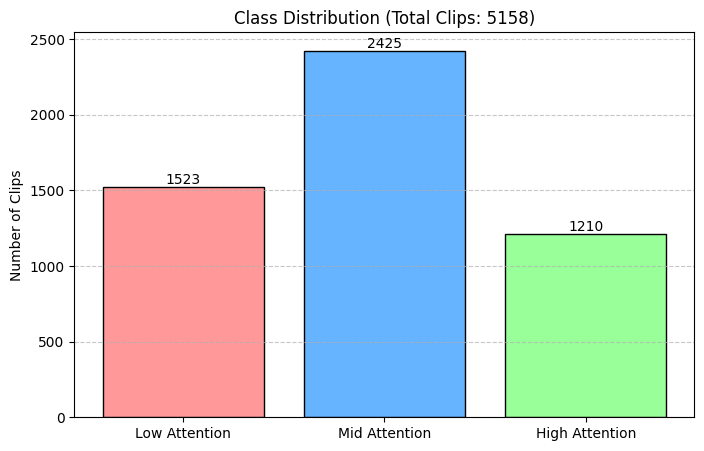

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

# ================= CONFIGURATION =================
# Path to your processed .npy files
DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v2"

# Class Labels (0, 1, 2)
CLASS_NAMES = ["Low Attention", "Mid Attention", "High Attention"]

# ================= ANALYSIS SCRIPT =================

def analyze_class_distribution(data_dir):
    print(f"Scanning {data_dir} for label files...")

    # Find all files ending in _y.npy
    label_files = glob.glob(os.path.join(data_dir, "*_y.npy"))

    if len(label_files) == 0:
        print("No label files found! Check your path.")
        return

    print(f"Found {len(label_files)} subject files.")

    # Aggregate all labels into one giant list
    all_labels = []
    subject_stats = {} # To store per-subject breakdown

    for f in label_files:
        # Extract subject name (e.g., "subject_01")
        subj_name = os.path.basename(f).replace("_y.npy", "")

        # Load labels
        y = np.load(f)
        all_labels.append(y)

        # Store individual stats
        unique, counts = np.unique(y, return_counts=True)
        stats = dict(zip(unique, counts))
        subject_stats[subj_name] = stats

    # Combine into one array
    total_y = np.concatenate(all_labels)

    # ================= CALCULATE STATS =================
    unique_classes, total_counts = np.unique(total_y, return_counts=True)
    total_dict = dict(zip(unique_classes, total_counts))

    total_samples = len(total_y)

    print("\n" + "="*40)
    print("      GLOBAL DATASET STATISTICS      ")
    print("="*40)
    print(f"Total Video Clips: {total_samples}")

    for cls_idx in [0, 1, 2]:
        count = total_dict.get(cls_idx, 0)
        percent = (count / total_samples) * 100
        print(f"Class {cls_idx} ({CLASS_NAMES[cls_idx]}): {count} clips ({percent:.2f}%)")

    # ================= VISUALIZATION =================

    # 1. Bar Chart
    plt.figure(figsize=(8, 5))
    colors = ['#ff9999', '#66b3ff', '#99ff99'] # Red, Blue, Green

    # Ensure we plot 0 for missing classes
    plot_counts = [total_dict.get(i, 0) for i in range(3)]

    bars = plt.bar(CLASS_NAMES, plot_counts, color=colors, edgecolor='black')

    # Add count labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom')

    plt.title(f'Class Distribution (Total Clips: {total_samples})')
    plt.ylabel('Number of Clips')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

analyze_class_distribution(DATA_DIR)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import gc

# ================= CONFIGURATION =================
DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v2" # Updated to v2
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 25              # Increased epochs (Scheduler needs time to work)
WEIGHT_DECAY = 1e-2      # For AdamW regularization

# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# ================= 1. DATASET & LOADER =================

class VideoDataset(Dataset):
    def __init__(self, X_data, y_data, is_train=False):
        self.X = X_data
        self.y = y_data
        self.is_train = is_train

        # Standard normalization
        self.norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

        # Augmentation (Only for training)
        # Helps Class 2 (High) generalize better
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1)
        ])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        clip = self.X[idx] # (16, 224, 224, 3) uint8
        label = self.y[idx]

        # Convert to Tensor (16, 3, 224, 224) float 0-1
        clip = torch.from_numpy(clip).permute(0, 3, 1, 2).float() / 255.0

        # Apply Transforms per frame
        frames = []
        for frame in clip:
            if self.is_train:
                frame = self.aug(frame) # Apply augmentation
            frame = self.norm(frame)    # Apply normalization
            frames.append(frame)

        return torch.stack(frames), label

def load_data(data_dir):
    print(f"Loading data from {data_dir}...")
    x_files = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))
    y_files = sorted(glob.glob(os.path.join(data_dir, "*_y.npy")))

    if not x_files: raise ValueError("No data found! Check folder name.")

    # Load using memory mapping to avoid RAM explosion before split
    X_list = [np.load(f) for f in x_files]
    y_list = [np.load(f) for f in y_files]

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    return X_all, y_all

# Load
X_all, y_all = load_data(DATA_DIR)

# Stratified Split (80/20)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in splitter.split(X_all, y_all):
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

# Create Datasets
train_dataset = VideoDataset(X_train, y_train, is_train=True) # Augmentation ON
val_dataset = VideoDataset(X_val, y_val, is_train=False)      # Augmentation OFF

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Cleanup RAM
del X_all, y_all, X_train, X_val, y_train, y_val, X_list, y_list
gc.collect()

# ================= 2. MODEL t18 (ResNe+ LSTM) =================

class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetLSTM, self).__init__()

        # CNN Backbone
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)

        # Unfreeze last 2 layers of ResNet for fine-tuning features
        for param in self.cnn.parameters():
            param.requires_grad = False
        for param in self.cnn[-2:].parameters(): # Unfreeze last block
            param.requires_grad = True

        # LSTM (Temporal)
        self.lstm = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.5) # Prevent overfitting
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.size()
        c_in = x.view(b * t, c, h, w)

        # CNN Features
        c_out = self.cnn(c_in)
        c_out = c_out.view(b, t, -1) # (Batch, 16, 512)

        # LSTM
        r_out, _ = self.lstm(c_out)

        # Classification on last frame output
        out = self.fc(self.dropout(r_out[:, -1, :]))
        return out

model = ResNetLSTM(num_classes=3).to(device)

# ================= 3. OPTIMIZATION SETUP =================

# CALCULATED CLASS WEIGHTS: [1.13, 0.71, 1.42]
weights = torch.tensor([1.13, 0.71, 1.42]).float().to(device)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1) # Label smoothing helps generalisation
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# SCHEDULER: Reduce LR if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# ================= 4. TRAINING LOOP =================

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print("Starting Training (v2 Data)...")

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    # Step Scheduler
    scheduler.step(avg_val_loss)

    # Save Best Model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_attention_model_v2.pth')
        print(f"--> Best Model Saved (Val Loss: {best_val_loss:.4f})")

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# ================= 5. EVALUATION =================

print("\n--- Final Evaluation (Best Model) ---")
# Load best weights
model.load_state_dict(torch.load('/content/drive/MyDrive/best_attention_model_v2.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["Low", "Mid", "High"]))

# Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Mid", "High"],
            yticklabels=["Low", "Mid", "High"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (v2 Data)')
plt.show()

# Curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

Training on: cuda
Loading data from /content/drive/MyDrive/Processed_Clips_v2...


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import os
import glob
import shutil
import time
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================= CONFIGURATION =================
DRIVE_DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v2" # Your Drive Path
LOCAL_DATA_DIR = "/content/temp_data"                        # Local Colab SSD (Fast!)
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 20
WEIGHT_DECAY = 1e-2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ================= 1. FAST COPY TO LOCAL DISK =================
# We copy data from Drive to Colab's local SSD.
# This prevents "Input/Output" bottlenecks and keeps RAM free.

def copy_data_to_local(src_dir, dest_dir):
    if os.path.exists(dest_dir):
        print(f"Local data found at {dest_dir}, skipping copy.")
        return

    print(f"Copying data from Drive to Local Disk ({dest_dir})...")
    print("This takes 1-2 minutes but makes training 10x faster.")
    os.makedirs(dest_dir, exist_ok=True)

    files = glob.glob(os.path.join(src_dir, "*.npy"))
    if not files: raise ValueError("No files found in Drive path!")

    for f in files:
        shutil.copy(f, dest_dir)

    print(f"Copy complete! {len(files)} files moved.")

copy_data_to_local(DRIVE_DATA_DIR, LOCAL_DATA_DIR)

# ================= 2. LAZY DATASET (RAM SAFE) =================

class LazyVideoDataset(Dataset):
    def __init__(self, index_map, is_train=False):
        """
        Args:
            index_map: List of tuples [(file_path, local_index, label), ...]
        """
        self.index_map = index_map
        self.is_train = is_train

        self.norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1)
        ])

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        # 1. Unpack info
        file_path, local_idx, label = self.index_map[idx]

        # 2. Lazy Load: Open file ONLY when needed using mmap_mode='r'
        # This allows accessing a slice of the array without loading the whole file
        full_array = np.load(file_path, mmap_mode='r')

        # 3. Read specific clip (16, 224, 224, 3)
        # Copy to a fresh array to detach from the mmap file handle
        clip = np.array(full_array[local_idx])

        # 4. Preprocess
        # (16, 224, 224, 3) -> (16, 3, 224, 224)
        clip = torch.from_numpy(clip).permute(0, 3, 1, 2).float() / 255.0

        frames = []
        for frame in clip:
            if self.is_train:
                frame = self.aug(frame)
            frame = self.norm(frame)
            frames.append(frame)

        return torch.stack(frames), label

def build_index_map(data_dir):
    """
    Scans files and builds a map: Global_Index -> (File, Local_Index, Label)
    Loads ONLY labels into RAM.
    """
    print("Building Index Map (RAM Safe)...")
    y_files = sorted(glob.glob(os.path.join(data_dir, "*_y.npy")))
    x_files = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))

    full_index = []
    all_labels = []

    for x_f, y_f in zip(x_files, y_files):
        # Load labels (Tiny memory footprint)
        lbls = np.load(y_f)

        # For every clip in this file, create a reference
        for i, label in enumerate(lbls):
            full_index.append((x_f, i, label))
            all_labels.append(label)

    print(f"Total Clips Indexed: {len(full_index)}")
    return full_index, np.array(all_labels)

# Build Map
full_index, all_labels = build_index_map(LOCAL_DATA_DIR)

# Split indices
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = next(splitter.split(full_index, all_labels))

# Map subset indices back to the index_map
train_map = [full_index[i] for i in train_indices]
val_map = [full_index[i] for i in val_indices]

# Loaders
train_dataset = LazyVideoDataset(train_map, is_train=True)
val_dataset = LazyVideoDataset(val_map, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ================= 3. MODEL (ResNetLSTM) =================

class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetLSTM, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)

        # Unfreeze last block
        for param in self.cnn.parameters(): param.requires_grad = False
        for param in self.cnn[-2:].parameters(): param.requires_grad = True

        self.lstm = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.size()
        c_in = x.view(b * t, c, h, w)
        c_out = self.cnn(c_in)
        c_out = c_out.view(b, t, -1)
        r_out, _ = self.lstm(c_out)
        out = self.fc(self.dropout(r_out[:, -1, :]))
        return out

model = ResNetLSTM(num_classes=3).to(device)

# ================= 4. TRAINING SETUP =================

# Weights based on your distribution: Class 0 (~30%), Class 1 (~47%), Class 2 (~23%)
# Weights ~ [1.13, 0.71, 1.42]
class_weights = torch.tensor([1.13, 0.71, 1.42]).float().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
scaler = GradScaler() # Mixed Precision

# ================= 5. TRAINING LOOP =================

print("Starting RAM-Safe Training...")
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Val
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Save to Drive (Persistent storage)
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_attention_model_v2_opt.pth')
        print(f"--> Saved Best Model (Loss: {best_val_loss:.4f})")

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}%")


Device: cuda
Copying data from Drive to Local Disk (/content/temp_data)...
This takes 1-2 minutes but makes training 10x faster.
Copy complete! 40 files moved.
Building Index Map (RAM Safe)...
Total Clips Indexed: 5158
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


Starting RAM-Safe Training...


/tmp/ipython-input-580763767.py:177: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Mixed Precision
/tmp/ipython-input-580763767.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-580763767.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


--> Saved Best Model (Loss: 0.8558)
Epoch [1/20] Train Loss: 0.9480 | Val Acc: 65.12%
--> Saved Best Model (Loss: 0.8235)
Epoch [2/20] Train Loss: 0.8203 | Val Acc: 68.80%
--> Saved Best Model (Loss: 0.7563)
Epoch [3/20] Train Loss: 0.7459 | Val Acc: 72.38%
--> Saved Best Model (Loss: 0.7343)
Epoch [4/20] Train Loss: 0.6598 | Val Acc: 76.55%
--> Saved Best Model (Loss: 0.7179)
Epoch [5/20] Train Loss: 0.6140 | Val Acc: 77.81%
--> Saved Best Model (Loss: 0.7006)
Epoch [6/20] Train Loss: 0.5703 | Val Acc: 78.29%
Epoch [7/20] Train Loss: 0.5345 | Val Acc: 75.68%
Epoch [8/20] Train Loss: 0.5185 | Val Acc: 77.52%
Epoch [9/20] Train Loss: 0.4875 | Val Acc: 74.90%
Epoch [10/20] Train Loss: 0.4614 | Val Acc: 77.91%
--> Saved Best Model (Loss: 0.6925)
Epoch [11/20] Train Loss: 0.4207 | Val Acc: 80.33%
Epoch [12/20] Train Loss: 0.4046 | Val Acc: 80.23%
Epoch [13/20] Train Loss: 0.3959 | Val Acc: 80.62%
--> Saved Best Model (Loss: 0.6903)
Epoch [14/20] Train Loss: 0.3899 | Val Acc: 80.52%
--> Sav

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/best_attention_model_v2.pth'


--- Evaluation ---
              precision    recall  f1-score   support

         Low       0.74      0.75      0.75       305
         Mid       0.86      0.83      0.84       485
        High       0.81      0.83      0.82       242

    accuracy                           0.81      1032
   macro avg       0.80      0.81      0.80      1032
weighted avg       0.81      0.81      0.81      1032



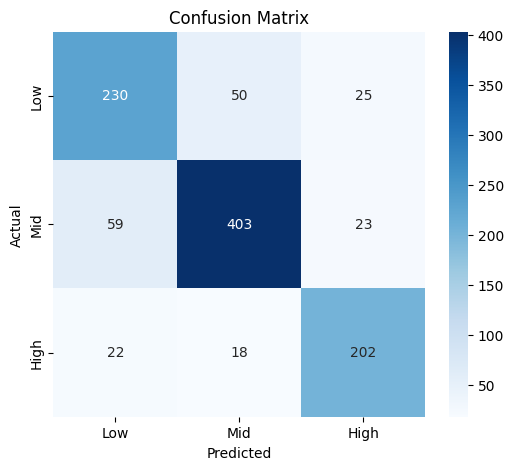

In [ ]:

# ================= 6. RESULTS =================

print("\n--- Evaluation ---")
model.load_state_dict(torch.load('/content/drive/MyDrive/best_attention_model_v2_opt.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["Low", "Mid", "High"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low", "Mid", "High"],
            yticklabels=["Low", "Mid", "High"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Testing on: cuda
✅ Model weights loaded.
Building Index Map...
Total Clips: 5158
Testing on Validation Subset: 1032 clips

Running Inference...

CLASSIFICATION REPORT
                precision    recall  f1-score   support

 Low Attention       0.74      0.75      0.75       305
 Mid Attention       0.86      0.83      0.84       485
High Attention       0.81      0.83      0.82       242

      accuracy                           0.81      1032
     macro avg       0.80      0.81      0.80      1032
  weighted avg       0.81      0.81      0.81      1032



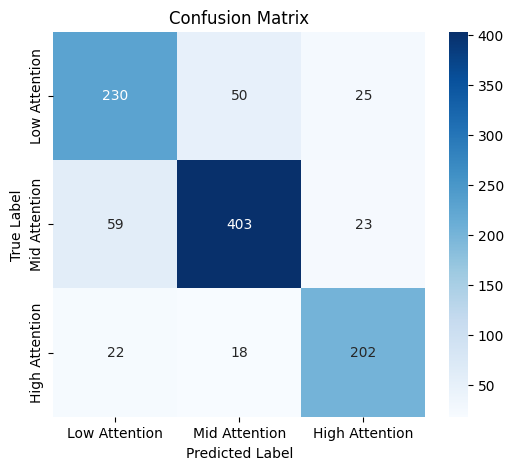


Visualizing 5 Random Clips...


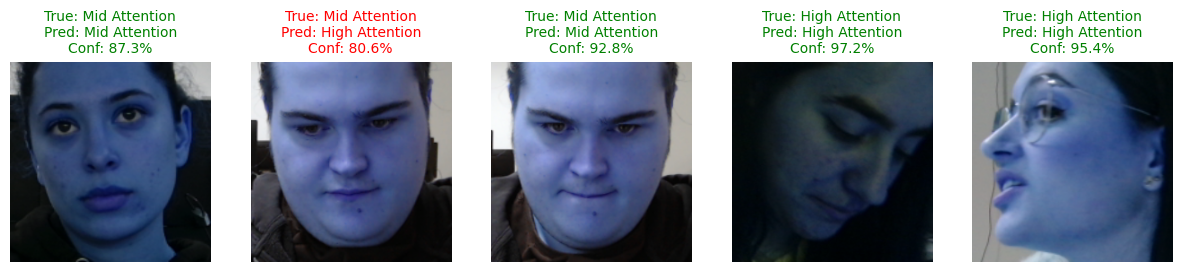

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

# ================= CONFIGURATION =================
MODEL_PATH = '/content/drive/MyDrive/best_attention_model_v2_opt.pth'
DATA_DIR = "/content/drive/MyDrive/Processed_Clips_v2"
BATCH_SIZE = 32
CLASSES = ["Low Attention", "Mid Attention", "High Attention"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

# ================= 1. DEFINE MODEL ARCHITECTURE =================

class ResNetLSTM(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetLSTM, self).__init__()
        resnet = models.resnet18(weights=None)
        modules = list(resnet.children())[:-1]
        self.cnn = nn.Sequential(*modules)
        self.lstm = nn.LSTM(input_size=512, hidden_size=128, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.size()
        c_in = x.view(b * t, c, h, w)
        c_out = self.cnn(c_in)
        c_out = c_out.view(b, t, -1)
        r_out, _ = self.lstm(c_out)
        out = self.fc(self.dropout(r_out[:, -1, :]))
        return out

# Load Model
model = ResNetLSTM(num_classes=3).to(device)
if os.path.exists(MODEL_PATH):
    # Load onto CPU first to avoid GPU memory spikes, then move to device
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Model weights loaded.")
    model.eval()
else:
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}")

# ================= 2. LAZY DATASET (RAM SAFE) =================

class LazyVideoDataset(Dataset):
    def __init__(self, index_map):
        """
        Args:
            index_map: List of tuples [(file_path, local_index, label), ...]
        """
        self.index_map = index_map
        self.norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        file_path, local_idx, label = self.index_map[idx]

        # Lazy Load: Read only the slice we need from disk
        full_array = np.load(file_path, mmap_mode='r')
        clip = np.array(full_array[local_idx]) # Copy specific clip to RAM

        # Preprocess
        clip = torch.from_numpy(clip).permute(0, 3, 1, 2).float() / 255.0
        return torch.stack([self.norm(f) for f in clip]), label

def get_test_indices(data_dir):
    """
    Scans files and reconstructs the Validation Split using indices only.
    Does NOT load video data into RAM.
    """
    print("Building Index Map...")
    y_files = sorted(glob.glob(os.path.join(data_dir, "*_y.npy")))
    x_files = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))

    full_index = []
    all_labels = []

    # 1. Build Global Index Map
    for x_f, y_f in zip(x_files, y_files):
        lbls = np.load(y_f) # Only load labels (tiny)
        for i, label in enumerate(lbls):
            full_index.append((x_f, i, label))
            all_labels.append(label)

    # 2. Re-create the 80/20 Split
    # We use the same random_state=42 as training to ensure we test on the same Validation Set
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    _, test_idx_integers = next(splitter.split(full_index, all_labels))

    # 3. Extract the subset for testing
    test_map = [full_index[i] for i in test_idx_integers]

    print(f"Total Clips: {len(full_index)}")
    print(f"Testing on Validation Subset: {len(test_map)} clips")

    return test_map

# Prepare Data
test_map = get_test_indices(DATA_DIR)
test_dataset = LazyVideoDataset(test_map)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ================= 3. RUN EVALUATION =================

print("\nRunning Inference...")
all_preds = []
all_labels = []

# Buffers for visualization
vis_clips = []
vis_true = []
vis_pred = []
vis_probs = []
vis_indices = np.random.choice(len(test_dataset), 5, replace=False) # Pick 5 random indices to visualize

with torch.no_grad():
    batch_start = 0
    for i, (inputs, labels) in enumerate(test_loader):
        inputs = inputs.to(device)
        outputs = model(inputs)

        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        preds_np = predicted.cpu().numpy()
        labels_np = labels.numpy()
        probs_np = probs.cpu().numpy()

        all_preds.extend(preds_np)
        all_labels.extend(labels_np)

        # --- Capture data for visualization ---
        # Check if any of our chosen "random indices" are in this current batch
        batch_end = batch_start + inputs.size(0)

        for v_idx in vis_indices:
            if batch_start <= v_idx < batch_end:
                # Calculate local index in this batch
                local_idx = v_idx - batch_start

                # Un-normalize image for display
                # We take the first frame of the clip
                raw_frame = inputs[local_idx][0].cpu().permute(1, 2, 0).numpy()
                # Denormalize: (pixel * std) + mean
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                raw_frame = std * raw_frame + mean
                raw_frame = np.clip(raw_frame, 0, 1)

                vis_clips.append(raw_frame)
                vis_true.append(labels_np[local_idx])
                vis_pred.append(preds_np[local_idx])
                vis_probs.append(probs_np[local_idx])

        batch_start += inputs.size(0)

# --- METRICS ---
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# ================= 4. VISUAL CHECK =================

print(f"\nVisualizing {len(vis_clips)} Random Clips...")
if len(vis_clips) > 0:
    fig, axes = plt.subplots(1, len(vis_clips), figsize=(15, 3))
    if len(vis_clips) == 1: axes = [axes] # Handle single case

    for i, ax in enumerate(axes):
        true_l = vis_true[i]
        pred_l = vis_pred[i]
        prob = vis_probs[i][pred_l] * 100

        ax.imshow(vis_clips[i])
        ax.axis('off')

        color = 'green' if true_l == pred_l else 'red'
        title = f"True: {CLASSES[true_l]}\nPred: {CLASSES[pred_l]}\nConf: {prob:.1f}%"
        ax.set_title(title, color=color, fontsize=10)
    plt.show()

In [ ]:
import cv2
import torch
import mediapipe as mp
import numpy as np
import os
import glob
from torchvision import models, transforms
import torch.nn as nn

# ================= CONFIGURATION =================
DATASET_ROOT = "/content/drive/MyDrive/Behaviour Dataset"
OUTPUT_DIR = "/content/drive/MyDrive/Short_Demos"
MODEL_PATH = "/content/drive/MyDrive/student_attention_model.pth"

# Limits
FRAMES_TO_PROCESS = 200  # Process only first 200 frames (approx 20 seconds)
SUBJECTS_TO_TEST = 5     # How many different subjects to process

# Parameters
IMG_SIZE = 224
SEQ_LENGTH = 16
CLASSES = ["Low Attention", "Mid Attention", "High Attention"]
COLORS = [(0, 0, 255), (0, 255, 255), (0, 255, 0)] # Red, Yellow, Green

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= 1. LOAD MODEL =================
# (Assuming ResNetLSTM class is already defined in your notebook)
# If not, paste the class definition here again.

model = ResNetLSTM(num_classes=3).to(device)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded.")
else:
    raise FileNotFoundError("Model not found!")

transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ================= 2. MULTI-SUBJECT PROCESSING LOOP =================

def process_multiple_subjects_fast(root_dir, output_dir, frame_limit=200):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Find all subject folders
    subject_folders = sorted(glob.glob(os.path.join(root_dir, "subject_*")))

    # Limit number of subjects
    subject_folders = subject_folders[:SUBJECTS_TO_TEST]

    print(f"Found {len(subject_folders)} subjects to test.")

    # Initialize Face Detector once
    mp_face = mp.solutions.face_detection
    detector = mp_face.FaceDetection(model_selection=1, min_detection_confidence=0.5)

    for subject_path in subject_folders:
        subj_name = os.path.basename(subject_path)
        img_dir = os.path.join(subject_path, "images")

        if not os.path.exists(img_dir): continue

        print(f"\n[{subj_name}] Collecting images...")
        images = sorted(os.listdir(img_dir))
        images = [img for img in images if img.lower().endswith(('.jpg', '.png'))]

        if not images: continue

        # --- OPTIMIZATION: SLICE THE LIST ---
        # Only take the first N frames
        images = images[:frame_limit]
        print(f"[{subj_name}] Processing {len(images)} frames...")

        # Setup Video Writer
        save_path = os.path.join(output_dir, f"{subj_name}_demo.mp4")
        first_frame = cv2.imread(os.path.join(img_dir, images[0]))
        h, w, _ = first_frame.shape
        out = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'mp4v'), 10.0, (w, h))

        # Reset Buffers for new subject
        frame_buffer = []
        prediction_buffer = "Init..."
        color_buffer = (255, 255, 255)
        last_box = None

        for i, img_name in enumerate(images):
            frame = cv2.imread(os.path.join(img_dir, img_name))
            if frame is None: continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = detector.process(rgb)
            crop = None

            # --- LARGEST FACE LOGIC ---
            if results.detections:
                max_area = 0
                best_det = None

                for det in results.detections:
                    bbox = det.location_data.relative_bounding_box
                    area = bbox.width * bbox.height
                    # Must be > 5% of screen
                    if area > max_area and area > 0.05:
                        max_area = area
                        best_det = det

                if best_det:
                    d = best_det.location_data.relative_bounding_box
                    x, y = int(d.xmin * w), int(d.ymin * h)
                    bw, bh = int(d.width * w), int(d.height * h)

                    x, y = max(0, x-10), max(0, y-10)
                    bw, bh = min(w-x, bw+20), min(h-y, bh+20)
                    last_box = (x, y, bw, bh)
                    crop = frame[y:y+bh, x:x+bw]

            # Imputation
            if crop is None and last_box:
                x, y, bw, bh = last_box
                crop = frame[y:y+bh, x:x+bw]

            # Inference
            if crop is not None:
                try:
                    c_rez = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
                    c_ten = torch.from_numpy(c_rez).permute(2, 0, 1).float() / 255.0
                    frame_buffer.append(transform(c_ten))
                except: pass

            if len(frame_buffer) > SEQ_LENGTH: frame_buffer.pop(0)

            if len(frame_buffer) == SEQ_LENGTH:
                inp = torch.stack(frame_buffer).unsqueeze(0).to(device)
                with torch.no_grad():
                    out_vec = model(inp)
                    probs = torch.softmax(out_vec, dim=1)
                    idx = torch.argmax(probs).item()
                    prediction_buffer = f"{CLASSES[idx]} {probs[0][idx]:.2f}"
                    color_buffer = COLORS[idx]

            # Draw
            if last_box:
                x, y, bw, bh = last_box
                cv2.rectangle(frame, (x, y), (x+bw, y+bh), color_buffer, 2)

            cv2.rectangle(frame, (0, 0), (w, 40), (0,0,0), -1)
            cv2.putText(frame, prediction_buffer, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_buffer, 2)

            out.write(frame)

        out.release()
        print(f"[{subj_name}] Saved video to {save_path}")

    detector.close()
    print("\nAll demos generated!")

# Run it
process_multiple_subjects_fast(DATASET_ROOT, OUTPUT_DIR, frame_limit=FRAMES_TO_PROCESS)

Model loaded.
Found 5 subjects to test.

[subject_01] Collecting images...
[subject_01] Processing 200 frames...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


[subject_01] Saved video to /content/drive/MyDrive/Short_Demos/subject_01_demo.mp4

[subject_02] Collecting images...
[subject_02] Processing 200 frames...
[subject_02] Saved video to /content/drive/MyDrive/Short_Demos/subject_02_demo.mp4

[subject_03] Collecting images...
[subject_03] Processing 200 frames...
[subject_03] Saved video to /content/drive/MyDrive/Short_Demos/subject_03_demo.mp4

[subject_04] Collecting images...
[subject_04] Processing 200 frames...
[subject_04] Saved video to /content/drive/MyDrive/Short_Demos/subject_04_demo.mp4

[subject_05] Collecting images...
[subject_05] Processing 200 frames...
[subject_05] Saved video to /content/drive/MyDrive/Short_Demos/subject_05_demo.mp4

All demos generated!
